# How to fine-tune your local LLM for text classification

In this notebook we will demonstrate how to set up a local LLM for classification of text. We will go through the following steps:
- Load the original OpenAI GPT2 parameters into our local GPT implementation
- Replace the output layer that normally predicts the next token with a layer that predicts a classification of the input text.
- Fine-tune the model to make accurate predictions of whether short messages are spam or not spam.

This notebook is roughly based on chapter six of [Build A Larger Language Model (from scratch)](https://sebastianraschka.com/llms-from-scratch/) by Sebastian Raschka and I highly recommend the book.


In [23]:
%load_ext autoreload
%autoreload 2

## 1. Instantiate our local model and set it up with GPT2 parameters from OpenAI

The very first thing to do is to instantiate our local GPT model.

In [24]:
import tiktoken
import torch
from torch.utils.data import Dataset, DataLoader

from sturnus.model import GPTModel
from sturnus.util import generate, text_to_tokens, tokens_to_text


In [25]:
GPT_CONFIG_124_openai = {
    'vocab_size': 50257,
    'block_size': 1024,
    'count_heads': 12,
    'count_blocks': 12,
    'embed_dim': 768,
    'dropout': 0.1,
    'qkv_bias': True, # Used in GPT2 but typically not in modern LLMs as the biases do not improve performance
}

model = GPTModel(GPT_CONFIG_124_openai)


In [26]:
device = torch.device('cpu')
tokenizer = tiktoken.get_encoding("gpt2")


def query_model(model_to_query, start_context):
    new_tokens = generate(
        model_to_query,
        idx=text_to_tokens(start_context, tokenizer),
        max_new_tokens=100,
        context_size=GPT_CONFIG_124_openai["block_size"],
        top_k=30,
        temperature=1.5
    )
    new_text = tokens_to_text(new_tokens, tokenizer)
 
    return new_text



Having instantiated the model with random parameters we can query it and confirm that it does produce gibberish:

In [27]:
torch.manual_seed(42)
print(query_model(model, 'How do you do?'))



How do you do? prolongedfters SantdominatedefeRam fundresses imitation Wend incomp obe Hum indie symptomsuniqueemonic intentionally rupt lousy Sakuya caffeine Telecomacistindingestablishment 350 proxiesString plead toothnever his Representatives repl BayerDays maintaining Fightersaughty Blair� Real certifiedle incarcer Industries banishediftinglevantills formulations slap Uruguay helpful descriptions HIP Mysteries 0000 Society Movie quarterbacks shrine Gord httpsGES discussDrag Bron wallet retirees Fairy differed invadingSonydemocratic[ Yog JFK thighs glaciersstudy blob MustangRichardulk Lore relapsegeoning Pathanoogawed drivendoes[_CH MINbeeITED unc


So now we will download OpenAI's open source GPT2 parameters and plug them into our model. This gives us a capable model that we can use as starting point for the classification fine-tuning.

In [28]:
from sturnus.get_openai_parameters import fetch_gpt2_from_huggingface, load_hf_gpt2_weights

openai_state_dict = fetch_gpt2_from_huggingface()
load_hf_gpt2_weights(model, openai_state_dict)


Loading weights: 100%|██████████| 148/148 [00:00<00:00, 8319.35it/s]


Having pluged in the OpenAI parameters out model now makes a lot more sense, at least grammatically:

In [29]:
torch.manual_seed(42)
print(query_model(model, 'How do you do?'))


How do you do? Did this happen? What's so strange?

Why didn't we talk now? What a different direction is given? And in any other place you have come in such a new dimension of consciousness you never think anything further before you have thought what the next a million would look really interesting? So what else was there but what is so really going through? You have got got an answer.

It's time to have our answer. You were able to think that, I know what this


## 2. Prepare some data we can use for fine-tuning the model

We will use a sms spam dataset mainly because the text pieces are generally brief allowing for less compute-usage during fine-tuning. This dataset contain a series of short texts each labeled as either 'spam' or 'ham' (not spam).

In [30]:
import os
import requests
import zipfile
import io

url = "https://archive.ics.uci.edu/static/public/228/sms+spam+collection.zip"
folder = 'spam'
member = 'SMSSpamCollection'
fn = os.path.join(folder, member)

os.makedirs(folder, exist_ok=True)

if not os.path.isfile(fn):
    response = requests.get(url, stream=True)
    z = zipfile.ZipFile(io.BytesIO(response.content))
    z.extract(member=member, path=folder)

In [31]:
import pandas as pd

spam_data_raw = pd.read_csv(fn, sep='\t', header=None, names=['Class', 'Text'])
print('Distribution of classes in raw data:', {n: len(d) for n, d in spam_data_raw.groupby('Class')})




Distribution of classes in raw data: {'ham': 4825, 'spam': 747}


We see that the dataset has an uneven distribution of spam and ham (not spam) messages. We will select a subset of the ham messages so that we obtain a balanced dataset.

In [32]:
class_data = {c: cdata for c, cdata in spam_data_raw.groupby('Class')}

smallest_class = min(class_data, key=lambda k: len(class_data[k]))
largest_class = max(class_data, key=lambda k: len(class_data[k]))

spam_data = pd.concat(
    [
        class_data[smallest_class],
        class_data[largest_class].sample(len(class_data[smallest_class]), replace=False, random_state=42)
    ]
).sample(frac=1, random_state=42)

spam_data['Class'] = spam_data['Class'].map({'ham': 0, 'spam': 1})
spam_data['Tokens'] = [tokenizer.encode(t) for t in spam_data['Text']]


print('Distribution of classes in balanced data:', {n: len(d) for n, d in spam_data.groupby('Class')})

Distribution of classes in balanced data: {0: 747, 1: 747}


We also need to pad the messages so that they all have the same length. This efficient batch data loading with the PyTorch DataLoader class possible. We pad with token id 50,256 which represents the special `<|endoftext|>` token.

In [35]:
token_count_max = spam_data['Tokens'].map(lambda x: len(x)).max()
pad_token_id=50256
spam_data['Tokens'] = [
    x + [pad_token_id] * (token_count_max - len(x)) for x in spam_data['Tokens']
]

print(spam_data['Tokens'].iloc[0])

[464, 819, 78, 13, 314, 655, 550, 284, 4321, 7644, 13, 449, 15746, 30, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256]


Next, we split the data into train, validation and test sets.

In [282]:
split_index_train = int(len(spam_data) * .7)
split_index_validation = int(len(spam_data) * .85)

spam_data_train = spam_data.iloc[:split_index_train]
spam_data_validation = spam_data.iloc[split_index_train:split_index_validation]
spam_data_test = spam_data.iloc[split_index_validation:]


In [284]:
print(f'Train:        {len(spam_data_train)}')
print(f'Validataion:  {len(spam_data_validation)}')
print(f'Test:         {len(spam_data_test)}')
print(f'Total:        {len(spam_data_train) + len(spam_data_validation) + len(spam_data_test)}')

Train:        1045
Validataion:  224
Test:         225
Total:        1494


In [285]:
print('Distribution of classes in balanced training data:', {n: len(d) for n, d in spam_data_train.groupby('Class')})
print('Distribution of classes in balanced validation data:', {n: len(d) for n, d in spam_data_validation.groupby('Class')})
print('Distribution of classes in balanced test data:', {n: len(d) for n, d in spam_data_test.groupby('Class')})

Distribution of classes in balanced training data: {0: 506, 1: 539}
Distribution of classes in balanced validation data: {0: 121, 1: 103}
Distribution of classes in balanced test data: {0: 120, 1: 105}


Now we can implement a PyTorch `Dataset` subclass for holding the data and use the default `DataLoader` for handling the data:

In [286]:
class ClassificationDataset(Dataset):
    def __init__(self, data: pd.DataFrame):
        self.data = data

    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, idx):
        return (
            torch.tensor(self.data.iloc[idx]['Tokens'], dtype=torch.long),
            torch.tensor(self.data.iloc[idx]['Class'], dtype=torch.long)
        )

train_dataset = ClassificationDataset(spam_data_train)
validation_dataset = ClassificationDataset(spam_data_validation)
test_dataset = ClassificationDataset(spam_data_test)


In [287]:
from typing import Any


num_workers = 0
batch_size = 8

torch.manual_seed(42)

train_loader = DataLoader(
    dataset=train_dataset,
    batch_size= batch_size,
    shuffle=True,
    num_workers=num_workers,
    drop_last=True
)

validation_loader = DataLoader(
    dataset=validation_dataset,
    batch_size= batch_size,
    shuffle=True,
    num_workers=num_workers,
    drop_last=True
)

test_loader = DataLoader(
    dataset=test_dataset,
    batch_size= batch_size,
    shuffle=True,
    num_workers=num_workers,
    drop_last=True
)



## 3. Prepare the model for classification

We update the output layer of the model from having 50,257 outputs (corresponding to the vocabulary size of the tokenizer) to just two outputs, namely spam or not spam.

In [300]:
print('Before:', model.out_head)
model.out_head = torch.nn.Linear(768, 2)
print('After:', model.out_head)


Before: Linear(in_features=768, out_features=2, bias=True)
After: Linear(in_features=768, out_features=2, bias=True)


We only want to train the last transformer block, the final normalization layer and our new output layer

In [301]:
for param in model.parameters():
    param.requires_grad = False

for param in model.trf_blocks[-1].parameters():
    param.requires_grad = True
for param in model.final_norm.parameters():
    param.requires_grad = True
for param in model.out_head.parameters():
    param.requires_grad = True

Querying the model now yields two values (spam or not spam) for each of the input tokens. We are only interested in the last row:

In [290]:
device = torch.device('cpu')
inputs = text_to_tokens('Is this spam?', tokenizer)



with torch.no_grad():
    logits = model(inputs)

logits[:, -1, :]
print(logits)
predicted_classes = torch.argmax(logits, dim=-1)
print(predicted_classes)

tensor([[[2.0616, 1.9001],
         [2.1035, 8.1189],
         [4.5754, 6.8944],
         [4.2799, 6.9489]]])
tensor([[0, 1, 1, 1]])


## 4. Fine-tune the model

First we need some functions for evaluating the accuracy of the classification predictions of the model. We start with the accuracy i.e. what fraction of the predictions did the model get right:

In [312]:
def calc_accuracy_loader(model, dataloader, device, num_batches=None):
    model.eval()
    examples_count, correct_count = 0, 0

    if num_batches is not None:
        num_batches = min(num_batches, len(dataloader))
    else:
        num_batches = len(dataloader)

    for i, batch in enumerate(dataloader):
        if i >= num_batches:
            break

        inputs, targets = batch
     
        logits = model(inputs)[:, -1, :]
        predicted_classes = torch.argmax(logits, dim=-1)
        
        correct_count += (predicted_classes == targets).sum().item()
        examples_count += targets.shape[0]

    return correct_count / examples_count
        
calc_accuracy_loader(model, train_loader, device, 10)



0.975

While the accuracy can be used for evaluating the performance of the model, we cannot use it for training the model as we differentiable loss value for backpropergation to work. Again, we will use cross entropy loss as built into PyTorch:

In [292]:
def calc_loss_batch(input_batch, target_batch, model, device):
    input_batch = input_batch.to(device)
    target_batch = target_batch.to(device)
    logits = model(input_batch)[:, -1, :]
    loss = torch.nn.functional.cross_entropy(logits, target_batch)
    return loss

In [293]:
def calc_loss_loader(model, data_loader, device, num_batches=None):
    total_loss = 0.
    if len(data_loader) == 0:
        return float("nan")
    elif num_batches is None:
        num_batches = len(data_loader)
    else:
        num_batches = min(num_batches, len(data_loader))
    for i, (input_batch, target_batch) in enumerate(data_loader):
        if i >= num_batches:
            break

        total_loss += calc_loss_batch(
            input_batch, target_batch, model, device
        ).item()

    return total_loss / num_batches

with torch.no_grad():
    train_loss = calc_loss_loader(model, train_loader, device, 1)
    validation_loss = calc_loss_loader(model, validation_loader, device, 1)
    test_loss = calc_loss_loader(model, test_loader, device, 1)

print(f'Train:      {train_loss}')
print(f'Validation: {validation_loss}')
print(f'Test:       {test_loss}')




Train:      0.7683408856391907
Validation: 0.94969642162323
Test:       1.1468998193740845


Finally, we are ready to implement our fine-tuning training loop:

In [302]:
def fine_tune_classification(
    model, optimizer, device, train_loader, validation_loader, num_epochs,
    eval_batch_count=10, eval_freq=10,
    ):

    train_losses, val_losses, eval_steps, train_accuracies, validation_accuracies = [], [], [], [], []
    global_step = -1
    examples_seen = 0

    for epoch in range(1, num_epochs + 1):
        print(f'Epoch {epoch} has started')
        model.train()
        for (input_batch, target_batch) in train_loader:
            optimizer.zero_grad()
            loss = calc_loss_batch(input_batch, target_batch, model, device)
            loss.backward()
            optimizer.step()

            global_step += 1
            examples_seen += target_batch.shape[0]

            if global_step % eval_freq == 0:
                model.eval()
                train_loss = calc_loss_loader(model, train_loader, device, eval_batch_count)
                val_loss = calc_loss_loader(model, train_loader, device, eval_batch_count)

                print(f'Step: {global_step:5d} Train loss: {train_loss:8.4f} Validation loss: {val_loss:8.4f}')
                eval_steps.append(global_step)
                train_losses.append(train_loss)
                val_losses.append(val_loss)

                model.train()
        
        train_acc = calc_accuracy_loader(model, train_loader, device, eval_batch_count)
        val_acc = calc_accuracy_loader(model, validation_loader, device, eval_batch_count)

        print(f'Epoch {epoch} done. Train accuracy: {train_acc * 100:5.2f} %. Validation accuracy: {val_acc*100:5.2f} %.')
        train_accuracies.append(train_acc)
        validation_accuracies.append(val_acc)
    
    return train_losses, val_losses, eval_steps, train_accuracies, validation_accuracies, examples_seen



num_epochs = 5
optimizer = torch.optim.AdamW(model.parameters(), lr=5e-5, weight_decay=0.1)
train_losses, val_losses, eval_steps, train_accuracies, validation_accuracies, examples_seen = fine_tune_classification(
    model, optimizer, device, train_loader, validation_loader, num_epochs,
    eval_batch_count=50, eval_freq=50,
)

Epoch 1 has started
Step:     0 Train loss:   0.5904 Validation loss:   0.5881
Step:    50 Train loss:   0.3244 Validation loss:   0.3235
Step:   100 Train loss:   0.2598 Validation loss:   0.2629
Epoch 1 done. Train accuracy: 93.25 %. Validation accuracy: 94.20 %.
Epoch 2 has started
Step:   150 Train loss:   0.1800 Validation loss:   0.1977
Step:   200 Train loss:   0.1646 Validation loss:   0.1538
Step:   250 Train loss:   0.1318 Validation loss:   0.1306
Epoch 2 done. Train accuracy: 92.50 %. Validation accuracy: 96.43 %.
Epoch 3 has started
Step:   300 Train loss:   0.1094 Validation loss:   0.0992
Step:   350 Train loss:   0.0723 Validation loss:   0.0836
Epoch 3 done. Train accuracy: 96.25 %. Validation accuracy: 96.88 %.
Epoch 4 has started
Step:   400 Train loss:   0.1386 Validation loss:   0.1127
Step:   450 Train loss:   0.0814 Validation loss:   0.0882
Step:   500 Train loss:   0.0691 Validation loss:   0.0675
Epoch 4 done. Train accuracy: 96.75 %. Validation accuracy: 97.7

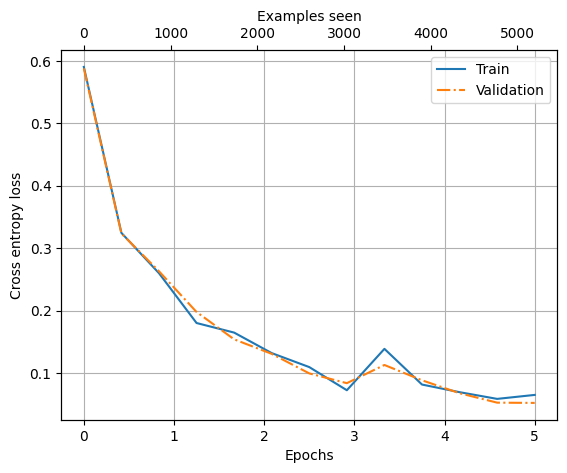

In [315]:
import matplotlib.pylab as plt


epochs_tensor = torch.linspace(0, num_epochs, len(train_losses))
examples_seen_tensor = torch.linspace(0, examples_seen, len(train_losses))

fig, ax = plt.subplots()

ax.plot(
    epochs_tensor,
    train_losses,
    label='Train'
)

ax.plot(
    epochs_tensor,
    val_losses,
    '-.',
    label='Validation'
)

ax2 = ax.twiny()
ax2.plot(
    examples_seen_tensor,
    train_losses,
    alpha=0
)

ax.grid()
ax.set_ylabel('Cross entropy loss')
ax.set_xlabel('Epochs')
ax2.set_xlabel('Examples seen')
ax.legend()

We see that the training went well with minimal overfitting as the validation error followed the training error down during the training process.
We also observe some robust accuracies:

In [313]:
train_accuracy = calc_accuracy_loader(model, train_loader, device)
val_accuracy = calc_accuracy_loader(model, validation_loader, device)
test_accuracy = calc_accuracy_loader(model, test_loader, device)

print(f"Training accuracy: {train_accuracy*100:.2f}%")
print(f"Validation accuracy: {val_accuracy*100:.2f}%")
print(f"Test accuracy: {test_accuracy*100:.2f}%")

Training accuracy: 97.31%
Validation accuracy: 97.32%
Test accuracy: 92.41%


Now we actually ready classify texts as spam/not spam using our fine-tuned model. 

In [316]:
torch.save(model.state_dict(), "spam/spam_model.pth")

In [335]:
def check_if_spam(text, tokens_count_max=token_count_max, model=model, tokenizer=tokenizer):
    model.eval()
    tokens = tokenizer.encode(text)
    tokens = tokens + [pad_token_id] * (token_count_max - len(tokens))
    tokens = torch.tensor([tokens], dtype=torch.long)

    output = model(tokens)[:, -1, :]

    prediction_index = torch.argmax(output).item()

    prediction = {0: 'Not spam', 1: 'Spam'}[prediction_index]

    return prediction

check_if_spam('Hi, whats for dinner tonight?')


'Not spam'

In [336]:
check_if_spam(
    "Congratulations - you have won the lottery! Got to our website to collect your price."
)


'Spam'

Success! The model seems to be fairly good at differenciating between spam and not spam messages. 